# **Analisis variables - Adultos vs Kids**

Este análisis contiene datos actualizados respecto al análisis presentado en la memoria y la presentación, por lo cuál hay algunas diferencias ligeras en las conclusiones. En algunos casos mencionamos también las conclusiones sacadas en el análisis anterior, ya que proporcionan información adicional relevante.

# Bibliotecas

In [ ]:
#Carga de datos
import pandas as pd
import json
import numpy as np
from Server_PD import download_dataframe_minio

from collections import Counter
import re

#Graficas
import seaborn as sns
import matplotlib.pyplot as plt
import isodate

from itertools import combinations
import ast
import os
from pathlib import Path

import analisisutils as utils
import filter_and_divide_data as filter


c:\Trabajos\c2526-R1\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


# Carga de datos

In [2]:
print(os.getcwd())

c:\Trabajos\c2526-R1\src\analisis


In [3]:
#Arreglamos la ruta
root = Path().resolve().parents[1]  
os.chdir(root)
print(os.getcwd())
df = filter.download_latest_extraction_correct(0)
df_fil = filter.download_latest_extraction_correct(2)
print(f'Tamaño de dataset sin filtrar: {len(df)}')
print(f'Tamaño de dataset filtrado: {len(df_fil)}')

C:\Trabajos\c2526-R1
Filtrando datos, con filtro de subtitulos
Numero de videos con duraciones atípicas: 2263
Numero de videos sin información textual: 766
Numero de videos con poca representación de generos: 1000
Guardamos aproximadamente  11 % de videos sin subtitulos para niños y adultos
La longitud antes de filtrar los subtitulos era  19103 y ahora es  6442
Tenemos  1273  videos de niños y  5169  videos de adultos
Hay  1151  videos de niños con subtítulos
Partiendo de 22896, se han eliminado 3793, resultando en: 19103 filas
Tamaño de dataset sin filtrar: 22896
Tamaño de dataset filtrado: 6442


# Dividimos los datos en "Adult" y "Kids"

In [4]:
df_Adult_fil, df_Kids_fil = utils.division_edad(df_fil)

print(f'Size of Kids filtrado: {len(df_Kids_fil)}')
print(f'Size of Adults filtrado: {len(df_Adult_fil)}')

df_Adult, df_Kids = utils.division_edad(df)

print(f'Size of Kids sin filtrar: {len(df_Kids)}')
print(f'Size of Adults sin filtrar: {len(df_Adult)}')

Size of Kids filtrado: 1273
Size of Adults filtrado: 5169
Size of Kids sin filtrar: 16974
Size of Adults sin filtrar: 5922


Como podemos obervar el numero de vídeos de niños es muchísimo mayor que el número de vídeos de adultos (74%). Sin embargo, tras filtrar videos con poca información textual (sin subtitulos) la proporción de niños cae en picado (20%). 

Esto nos está informando que los vídeos de niño tienden a no tener subtitulos. 

En este notebook de analisis nos vamos a centrar principalmente en los dataframes filtrados debido a que estos se van a utilizar para el entrenamiento de modelos. Sin embargo, también se mostrará información sobre los dataframes sin filtrar para observar los cambios producidos. 

# Análisis no textual

## Duración

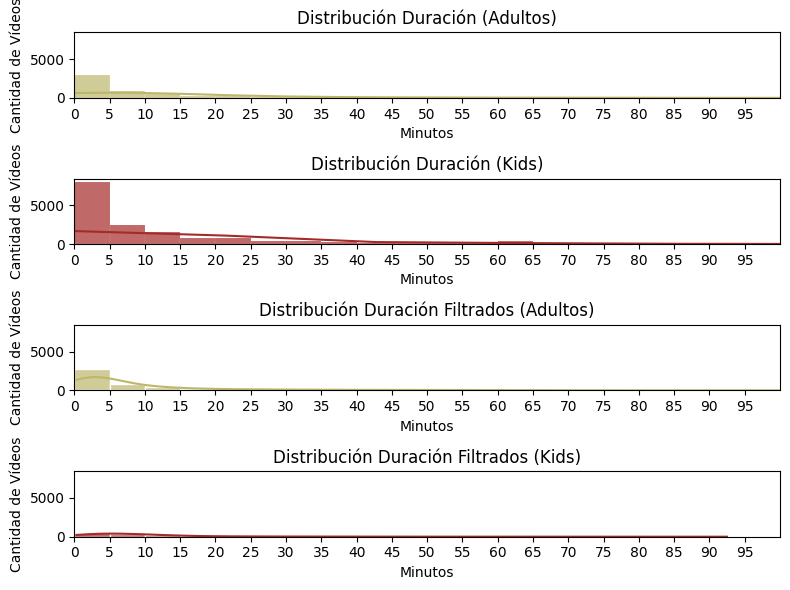

In [6]:

# Configuración
fig, ax = plt.subplots(4, 1, figsize=(8, 6), sharey=True)

utils.graficar_histograma_duracion(df_Adult, 'Distribución Duración (Adultos)', ax[0], 'darkkhaki')
utils.graficar_histograma_duracion(df_Kids, 'Distribución Duración (Kids)', ax[1], 'brown')

utils.graficar_histograma_duracion(df_Adult_fil, 'Distribución Duración Filtrados (Adultos)', ax[2], 'darkkhaki')
utils.graficar_histograma_duracion(df_Kids_fil, 'Distribución Duración Filtrados (Kids)', ax[3], 'brown')

plt.tight_layout()
plt.show()

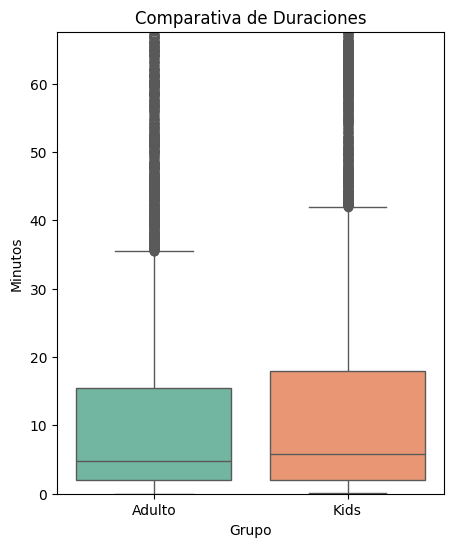

In [ ]:
df_total = pd.concat([
    df_Adult.assign(Grupo='Adulto'),
    df_Kids.assign(Grupo='Kids')
])

plt.figure(figsize=(5, 6))
sns.boxplot(x='Grupo', y='Duracion', data=df_total, palette='Set2')     

# zoom para que se vea mejor
limite_superior = df_total['Duracion'].quantile(0.95) * 0.7 
plt.ylim(0, limite_superior) 

plt.title('Comparativa de Duraciones')
plt.ylabel('Minutos')
plt.show()

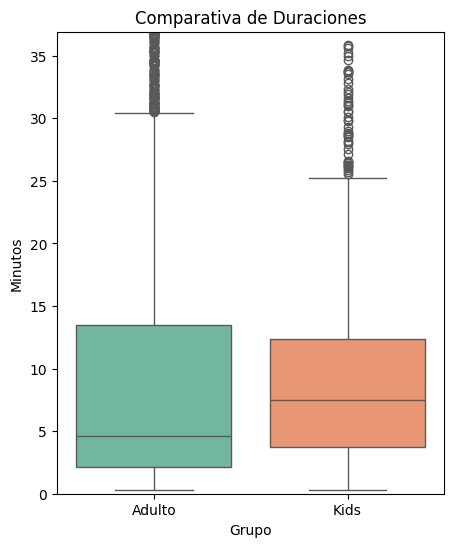

In [7]:
df_total = pd.concat([
    df_Adult_fil.assign(Grupo='Adulto'),
    df_Kids_fil.assign(Grupo='Kids')
])

plt.figure(figsize=(5, 6))
sns.boxplot(x='Grupo', y='Duracion', data=df_total, palette='Set2')     

# zoom para que se vea mejor
limite_superior = df_total['Duracion'].quantile(0.95) * 0.7 
plt.ylim(0, limite_superior) 

plt.title('Comparativa de Duraciones')
plt.ylabel('Minutos')
plt.show()

El historgrama de duración y los boxplots nos ayudan a sacar las siguientes conclusiones: 
- El filtrado cumple su funcion de eliminar bastante videos con duraciones excesivamente largas y cortas. Sin embargo, sigue pareciendo que hay muchos outliers con videos que superan los 30 minutos de duración (adults) o 25 minutos (kids). 
- También podemos ver que los vídeos de adultos suelen ser más cortos que los de niños, en torno a 2.5 minutos, pero hay más variedad de duración (caja más ancha). 
- La duración parece ser una buena variable para distinguir los tipos de vídeos. 

## Top 10 géneros

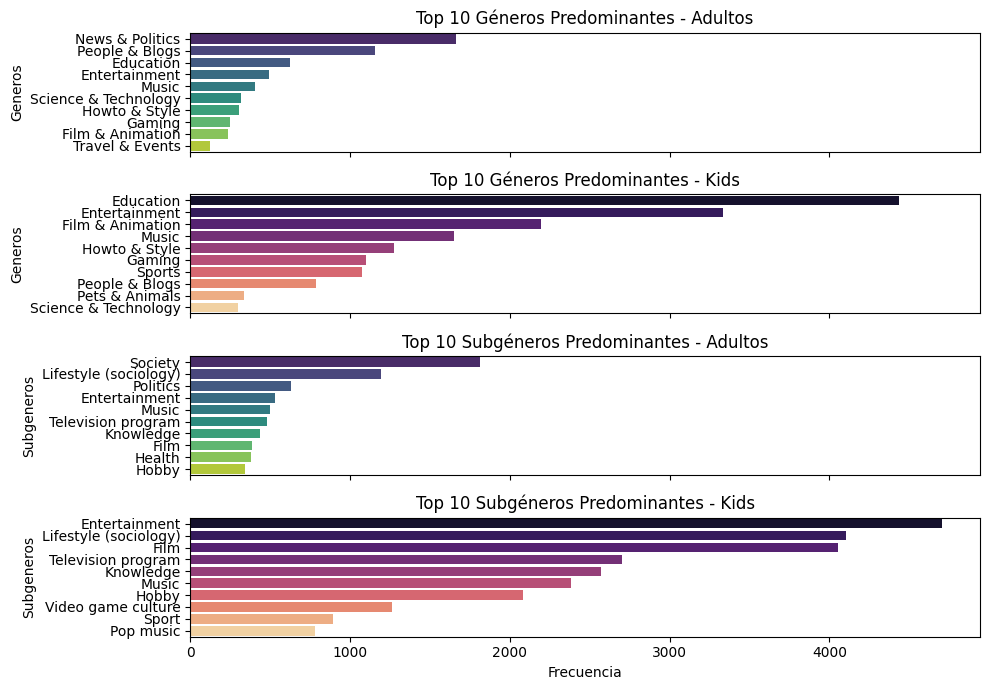

In [8]:
# Configuración
fig, ax = plt.subplots(4, 1, figsize=(10, 7), sharex=True)

# Llamamos a la función para cada grupo
utils.graficar_top_generos(df_Adult, 'Top 10 Géneros Predominantes - Adultos', ax[0], 'viridis', "Generos")
utils.graficar_top_generos(df_Kids, 'Top 10 Géneros Predominantes - Kids', ax[1], 'magma', "Generos")
utils.graficar_top_generos(df_Adult, 'Top 10 Subgéneros Predominantes - Adultos', ax[2], 'viridis', "Subgeneros")
utils.graficar_top_generos(df_Kids, 'Top 10 Subgéneros Predominantes - Kids', ax[3], 'magma', "Subgeneros")
plt.tight_layout()
plt.show()

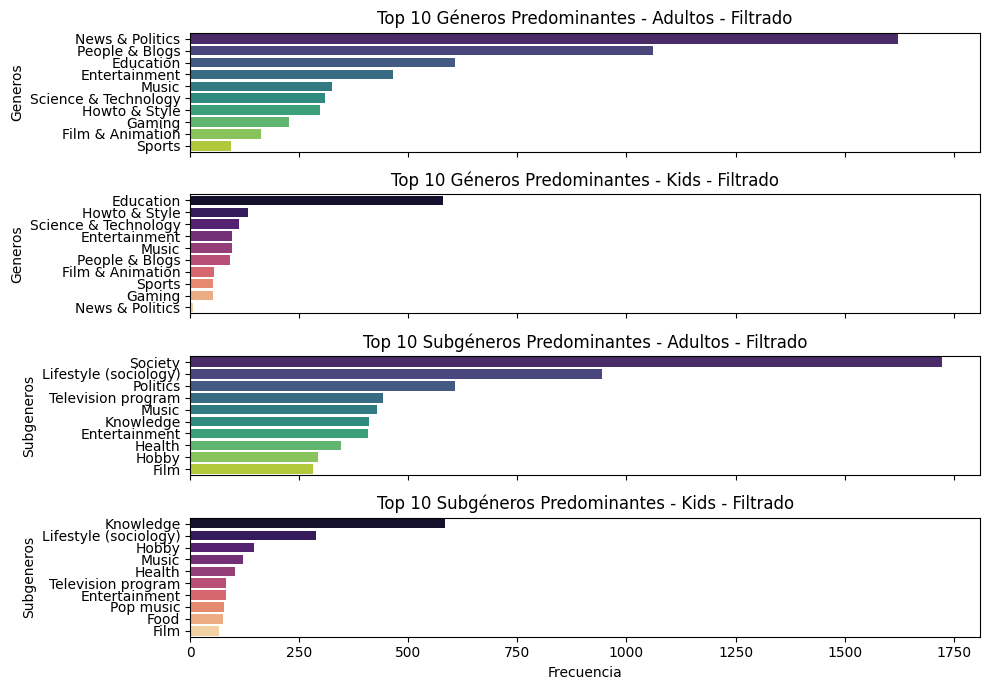

In [9]:
fig, ax = plt.subplots(4, 1, figsize=(10, 7), sharex=True)

# Llamamos a la función para cada grupo
utils.graficar_top_generos(df_Adult_fil, 'Top 10 Géneros Predominantes - Adultos - Filtrado', ax[0], 'viridis', "Generos")
utils.graficar_top_generos(df_Kids_fil, 'Top 10 Géneros Predominantes - Kids - Filtrado', ax[1], 'magma', "Generos")
utils.graficar_top_generos(df_Adult_fil, 'Top 10 Subgéneros Predominantes - Adultos - Filtrado', ax[2], 'viridis', "Subgeneros")
utils.graficar_top_generos(df_Kids_fil, 'Top 10 Subgéneros Predominantes - Kids - Filtrado', ax[3], 'magma', "Subgeneros")
plt.tight_layout()
plt.show()

A parte del genero "Education", que predomina en el grupo "kids", el resto de géneros orientados a un publico infantil son todos asociados al entrentenimiento. Mientras que en el grupo "Adultos" encontramos más variedad, incluyendo géneros como "News & Politics", que en el primer grupo que mencionamos casi no aparece.

En los subgéneros observamos un comportamiento muy similar, incluso con más diferencias.

Observamos que los géneros más voluminosos (Education, Entertainment) están presentes en ambos grupos. Esto genera una ambigüedad pero las diferencias notables con otros géneros como "News & Politics" o "Howto & Style" lo compensan y convierten género y subgéneros en variables mucho más importantes.

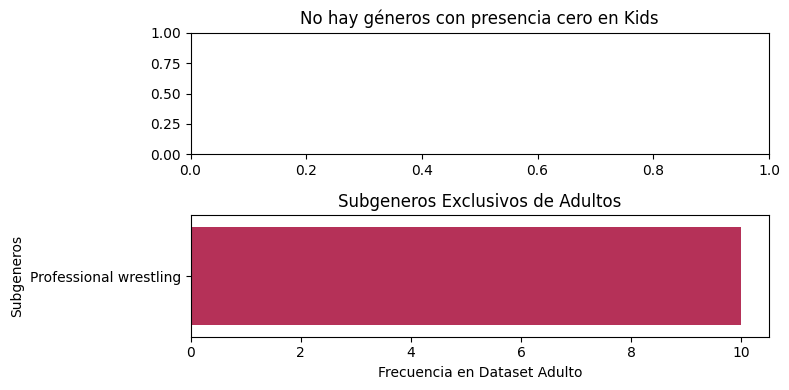

In [10]:
fig, ax = plt.subplots(2, 1, figsize=(8,4))
utils.graficar_generos_ausentes_kids(df_Adult, df_Kids, ax[0], "Generos")
utils.graficar_generos_ausentes_kids(df_Adult, df_Kids, ax[1], "Subgeneros")
plt.tight_layout()
plt.show()

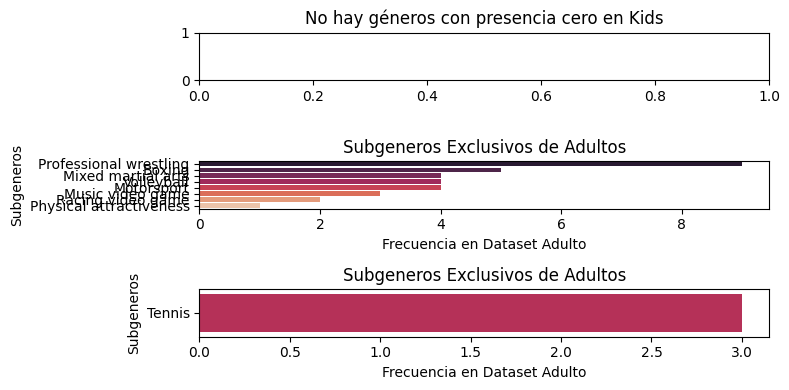

In [13]:
fig, ax = plt.subplots(3, 1, figsize=(8,4))
utils.graficar_generos_ausentes_kids(df_Adult_fil, df_Kids_fil, ax[0], "Generos")
utils.graficar_generos_ausentes_kids(df_Adult_fil, df_Kids_fil, ax[1], "Subgeneros")
utils.graficar_generos_ausentes_kids(df_Kids_fil, df_Adult_fil, ax[2], "Subgeneros")
plt.tight_layout()
plt.show()

Analizando las ausencias podemos ver que tanto en el filtrado como en el sin filtrar, todos los géneros aparecen en kids y adults. Sin embargo, subgéneros si que presenta ausencias más importantes. 

Podemos apreciar una tendencia a videos relacionados con deportes como vienen a ser "Boxing" y "Mixed martial arts" en los vídeos de adultos, los cuales no aparecen en los de niños 

En niños extrañamente hay videos con el subgénero tennis que no aparecen en adultos. No hay ninguna conclusión clara que se pueda obtener. 

## Densidad de habla (wpm)

In [14]:
#Agregamos una nueva columna a todos los df
df_Adult['Palabras_Por_Minuto'] = df_Adult.apply(utils.calcular_wpm, axis=1)
df_Adult['Palabras_Por_Minuto'] = round(df_Adult['Palabras_Por_Minuto'], 2)

df_Kids['Palabras_Por_Minuto'] = df_Kids.apply(utils.calcular_wpm, axis=1)
df_Kids['Palabras_Por_Minuto'] = round(df_Kids['Palabras_Por_Minuto'], 2)

df_Adult_fil['Palabras_Por_Minuto'] = df_Adult_fil.apply(utils.calcular_wpm, axis=1)
df_Adult_fil['Palabras_Por_Minuto'] = round(df_Adult_fil['Palabras_Por_Minuto'], 2)

df_Kids_fil['Palabras_Por_Minuto'] = df_Kids_fil.apply(utils.calcular_wpm, axis=1)
df_Kids_fil['Palabras_Por_Minuto'] = round(df_Kids_fil['Palabras_Por_Minuto'], 2)


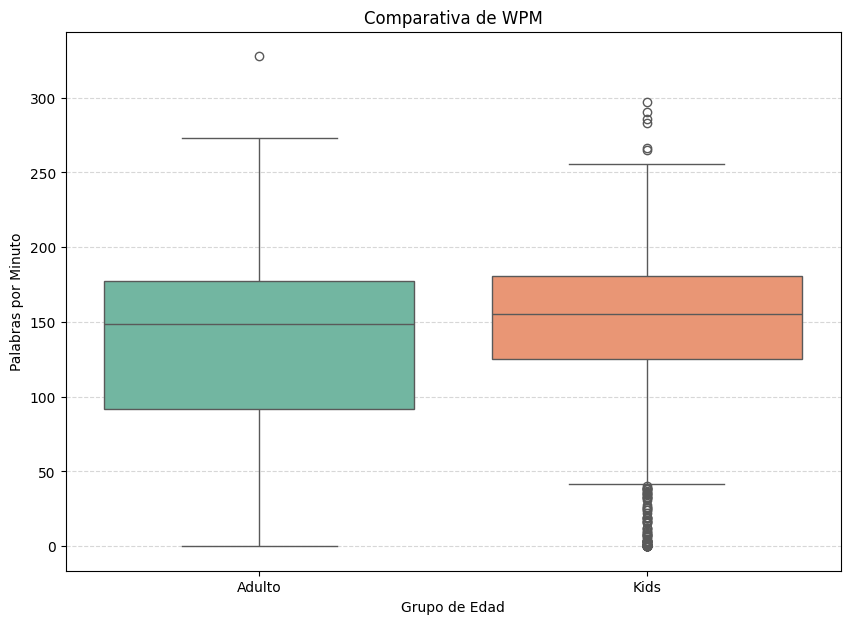

In [15]:
# Filtramos los vídeos sin palabras que no tienen subtitulos
df_wpm_total = pd.concat([
    df_Adult[df_Adult['Palabras_Por_Minuto'] > 0].assign(Grupo='Adulto'),
    df_Kids[df_Kids['Palabras_Por_Minuto'] > 0].assign(Grupo='Kids')
])

#Gráfica
plt.figure(figsize=(10, 7))

sns.boxplot(x='Grupo', y='Palabras_Por_Minuto', data=df_wpm_total, palette='Set2')

plt.title('Comparativa de WPM')
plt.xlabel('Grupo de Edad')
plt.ylabel('Palabras por Minuto')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

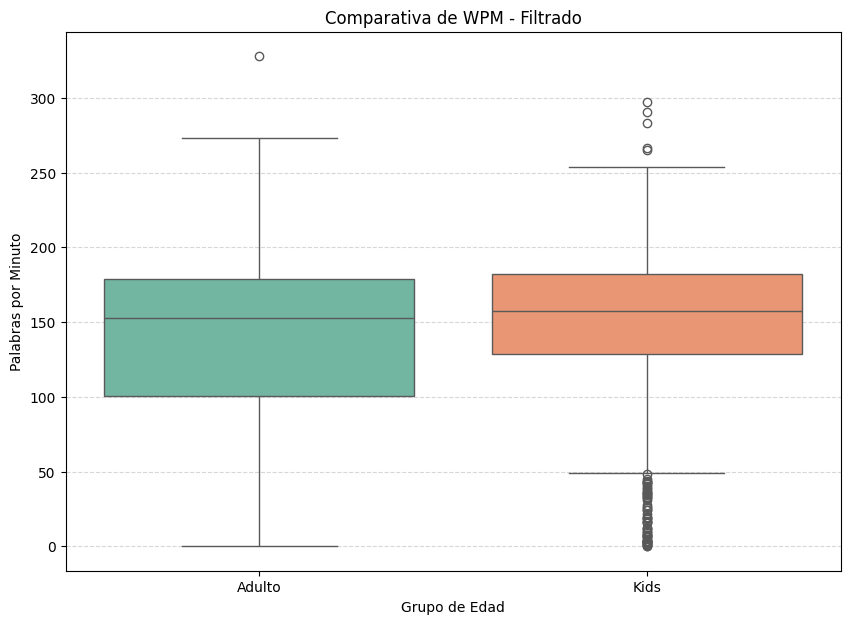

In [17]:
# Filtramos los vídeos sin palabras que no tienen subtitulos
df_wpm_total = pd.concat([
    df_Adult_fil[df_Adult_fil['Palabras_Por_Minuto'] > 0].assign(Grupo='Adulto'),
    df_Kids_fil[df_Kids_fil['Palabras_Por_Minuto'] > 0].assign(Grupo='Kids')
])

#Gráfica
plt.figure(figsize=(10, 7))

sns.boxplot(x='Grupo', y='Palabras_Por_Minuto', data=df_wpm_total, palette='Set2')

plt.title('Comparativa de WPM - Filtrado')
plt.xlabel('Grupo de Edad')
plt.ylabel('Palabras por Minuto')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Sorprendentemente, la mediana de palabras por minuto en el grupo Kids es ligeramente superior a la del grupo Adulto. Esto sugiere que, cuando un vídeo infantil es de carácter narrativo o educativo, mantiene un ritmo verbal constante y dinámico para mantener la atención del menor.

La caja del grupo infantil es notablemente más compacta. Esto indica que el contenido para niños sigue un estándar de producción muy rígido, el ritmo de habla es más uniforme.

El grupo Adulto presenta una caja mucho más amplia y bigotes más largos. Esto refleja la enorme heterogeneidad de su contenido; mientras que en Kids el ritmo es predecible, en adultos conviven géneros con una carga de guion mínima junto a otros de altísima densidad verbal.

También es sorprendente la cantidad de vídeos de kids con una duración anormalmente corta. Lo que da más peso a lo concentrado que es esa mediana. 

# Análisis textual

## Título

In [18]:
df_tf_titulo_kids = utils.tfidf_ngrams_titles(df_Kids_fil, "Titulo")
df_tf_titulo_adults = utils.tfidf_ngrams_titles(df_Adult_fil, "Titulo")


In [20]:
common_terms = utils.common_terms(df_tf_titulo_kids, df_tf_titulo_adults, "Titulo")

print(common_terms.sort_values("Diff", ascending=False).head(20))
common_terms.sort_values("Diff", ascending=True).head(20)

         Titulo  Score_kids  Score_adults       Diff
0       academy   23.252692      2.352166  20.900526
2        course   15.992841      4.327917  11.664924
5            mv   11.719181      1.697720  10.021460
7     minecraft   11.358640      2.178941   9.179699
1         crash   16.158760      8.873549   7.285211
16      lecture    7.824450      1.730824   6.093626
9          kids   10.121095      5.447466   4.673629
6       crochet   11.471478      7.135085   4.336393
35          mod    5.782483      1.446842   4.335641
34    chemistry    5.801194      1.661549   4.139645
39      biology    4.800773      0.964034   3.836739
47  official mv    4.516015      0.750391   3.765624
45         lego    4.610030      0.911921   3.698110
3       english   14.972531     11.434603   3.537927
33     knitting    5.920967      2.392164   3.528804
27       theory    6.613496      3.139696   3.473800
41      finance    4.776554      1.352565   3.423989
71         knit    3.468535      0.726359   2.

,Titulo,Score_kids,Score_adults,Diff
260,2026,1.794715,45.905606,-44.110891
18,new,7.569189,43.072074,-35.502885
535,ai,1.099487,28.617702,-27.518215
123,day,2.678875,25.838924,-23.160050
365,free,1.434665,21.963534,-20.528870
625,man,0.950967,21.117917,-20.166950
44,home,4.615911,24.085225,-19.469314
420,type,1.313601,18.187271,-16.873670
172,love,2.322171,17.419287,-15.097116
59,life,3.997934,18.576783,-14.578849


Podemos observar que las palabras más importantes para los videos infantiles son aquellas relacionadas con la educación (academy, course o lecture), además también aparece la palabra kids que tiene bastante en peso en revelar si el video es apto o no. 

Por otro lado, los vídeos de adultos aparecen más palabras sobre la actualidad/noticias (news, ai, 2026), conceptos más generales (free, love, live) o sobre vivienda (home, city)

In [21]:
kids_only, adults_only = utils.exclusive_terms(df_tf_titulo_kids, df_tf_titulo_adults, "Titulo")

print(adults_only.head(20))
kids_only.head(20)

         Titulo      Score
1643     county  21.039110
799        beat  19.038208
535       april  17.988941
6970  type beat  17.600550
5088     police  17.384087
6912      trump  15.152838
2553     family  15.048470
3679       just  13.832479
3557       iran  13.119320
7380      woman  11.883761
601        asmr  11.830720
4613       news  11.220964
7266    weather  10.927843
7018     update  10.906556
5859       says  10.577321
4443     mother  10.357122
1804       dark  10.341368
4433    morning  10.222826
1497  community   9.981224
3992     living   9.973225


,Titulo,Score
765,khan academy,23.109708
764,khan,23.109708
374,crash course,15.442824
740,introduction,7.969595
804,lec,7.077288
327,computerphile,6.218628
1071,physiology,5.798969
963,nclex rn,5.763206
964,nclex rn khan,5.763206
1214,rn khan,5.763206


La tabla de los adultos refleja una audiencia preocupada por la política.

El término dominante es "trump", junto con "iran" y "police". 
Esto indica un alto interés por conflictos internacionales actuales.

Los términos "asmr" y "type beat" son las únicas notas de entretenimiento, posiblemente usadas como métodos de relajación frente al resto de noticias estresantes.

En la tabla de niños el contenido es puramente formativo y se repiten los mismos canales populares continuamente como "khan" o "nclex"

Términos como "course" y "academy" lideran. La cantidad de vídeos divulgativos con función pedagogica es alta.

En la tabla de adultos, el lenguaje es técnico y serio ("forecast", "committee", "residents"). En la de niños, el lenguaje es funcional y descriptivo ("videos kids", "kids songs"). Esto demuestra que la búsqueda para niños directa y simple, mientras que para los adultos es específica y circunstancial.



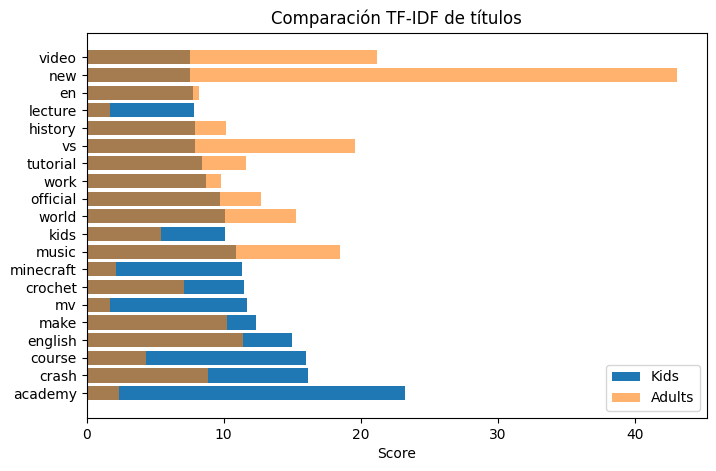

In [22]:
top_terms = common_terms.nlargest(20, "Score_kids")

plt.figure(figsize=(8,5))

plt.barh(top_terms["Titulo"], top_terms["Score_kids"], label="Kids")
plt.barh(top_terms["Titulo"], top_terms["Score_adults"], alpha=0.6, label="Adults")

plt.legend()
plt.title("Comparación TF-IDF de títulos")
plt.xlabel("Score")
plt.show()

In [24]:
topic_model_titulo, df_bertopic_titulo, temas_bertopic_titulo = utils.analizar_bertopic(df_fil, "Titulo")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [25]:
df_bertopic_titulo_adults, df_bertopic_titulo_kids = utils.division_edad(df_bertopic_titulo)

print(f'Size of Kids: {len(df_bertopic_titulo_kids)}')
print(f'Size of Adults: {len(df_bertopic_titulo_adults)}')


Size of Kids: 1273
Size of Adults: 5169


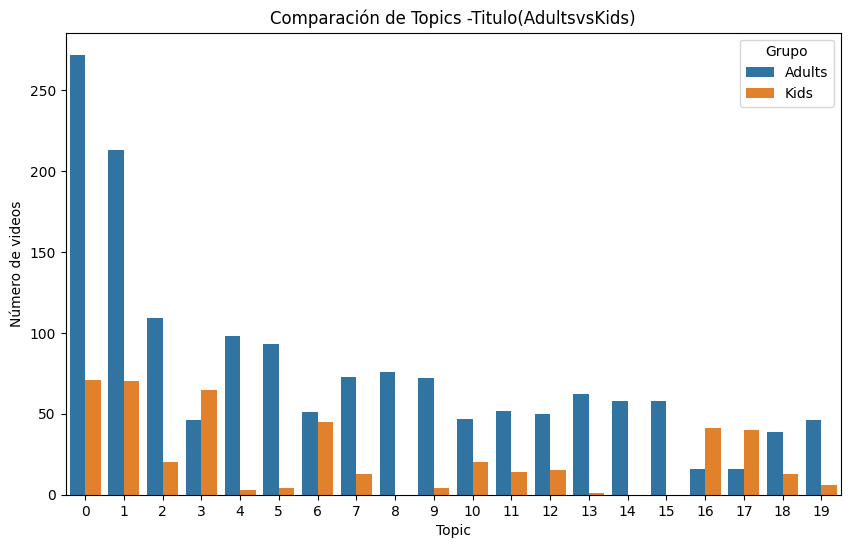

In [26]:
plt.figure(figsize=(10,6))
utils.graficar_bertopic(df_bertopic_titulo_adults, df_bertopic_titulo_kids, "Adults", "Kids", "Titulo")
plt.show()

In [28]:
topic_info = topic_model_titulo.get_topic_info()
topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2828,-1_the_to_of_in,"[the, to, of, in, and, for, how, is, with, on]",[The Distance Between You Isn’t Real… Here’s W...
1,0,343,0_recipe_food_delicious_cake,"[recipe, food, delicious, cake, make, cooking,...",[An old casserole recipe! Dinner in 15 minutes...
2,1,283,1_music_song_official_video,"[music, song, official, video, rock, lyrics, j...",[【BSS】AI Music《Beautiful Obsession 美麗的執念》Moder...
3,2,129,2_tax_government_trump_bill,"[tax, government, trump, bill, politics, news1...",[Congressional Elections: Crash Course Governm...
4,3,111,3_english_learn_grammar_practice,"[english, learn, grammar, practice, listening,...","[Learn English Grammar: The Sentence, 100 Dail..."
5,4,101,4_her_she_he_ceo,"[her, she, he, ceo, his, was, mother, stepmoth...","[[Multi SUB] Forced into marriage, but her fia..."
6,5,97,5_weather_forecast_storms_weekend,"[weather, forecast, storms, weekend, heat, fri...","[First Alert Weather Extra 4-16-26 segment #3,..."
7,6,96,6_finance_capital_khan_markets,"[finance, capital, khan, markets, academy, fin...",[Introduction to bonds | Stocks and bonds | Fi...
8,7,86,7_brain_why_self_you,"[brain, why, self, you, confidence, therapy, p...","[Why Your Brain Needs a ""Green Reset"" (The DNA..."
9,8,76,8_shooting_man_woman_shot,"[shooting, man, woman, shot, suspect, police, ...",[Tanglewood school shooting suspect pleads gui...


Como adultos es el género dominante en número, la mayoría de topics (grupos semánticos creados por bert) están relacionados con vídeos para adultos. Por ejemplo, los tópicos 0,1,2 (comida, música, gobierno).

Sin embargo, los tópicos 16 y 17 están dominados por niños (cálculo y medicina)

## Titulo canal


In [10]:
df_tf_titulo_canal_kids = utils.tfidf_ngrams_titles(df_Kids_fil, "Titulo_canal")
df_tf_titulo_canal_adults = utils.tfidf_ngrams_titles(df_Adult_fil, "Titulo_canal")

In [11]:
common_terms = utils.common_terms(df_tf_titulo_canal_kids, df_tf_titulo_canal_adults, "Titulo_canal")

print(common_terms.sort_values("Diff", ascending=False).head(20))
common_terms.sort_values("Diff", ascending=True).head(20)


     Titulo_canal  Score_kids  Score_adults       Diff
0         academy   66.097268      7.423603  58.673665
2        elsevier   13.856406      0.671051  13.185355
5            kids   10.450498      2.000000   8.450498
9         matters    7.749700      1.651042   6.098658
4         crochet   12.124356      6.493100   5.631256
17  learn english    5.863024      1.658891   4.204132
10    engineering    7.458113      3.323264   4.134849
8           learn    7.929077      4.111524   3.817553
13            old    6.480898      2.724228   3.756670
15           nick    6.116233      2.700057   3.416176
29        lessons    4.444376      1.619999   2.824377
6         science    9.609630      6.793441   2.816189
16             mr    6.018834      3.367274   2.651560
20         rachel    5.052734      2.496373   2.556361
7           house    9.075794      6.648052   2.427743
28           mark    4.618802      2.462607   2.156195
21          smart    5.000000      2.943096   2.056904
33        

,Titulo_canal,Score_kids,Score_adults,Diff
18,tv,5.382130,45.082889,-39.700759
45,channel,2.887284,29.750433,-26.863149
77,stories,1.258826,14.917972,-13.659146
24,world,4.780449,18.424243,-13.643793
27,studio,4.618802,18.208419,-13.589617
92,tech,0.816497,10.965738,-10.149241
86,new,1.077350,10.856039,-9.778688
3,music,12.206786,21.468750,-9.261965
41,official,3.115732,11.933427,-8.817695
75,health,1.440271,9.167144,-7.726873


In [12]:
kids_only, adults_only = utils.exclusive_terms(df_tf_titulo_canal_kids, df_tf_titulo_canal_adults, "Titulo_canal")

print(adults_only.head(20))
kids_only.head(20)

     Titulo_canal       Score
1522         news  149.175692
340           cbs   48.314805
718           fox   34.613097
589         drama   28.441443
29             13   24.303027
1477           ms   23.788783
1236         life   23.198835
23             12   22.801890
134            ai   22.060412
2329         wfaa   21.000000
1264        local   18.058821
26        12 news   17.268467
0              10   16.970500
2337         wfsb   15.000000
22        11alive   15.000000
89            abc   13.430989
1695      podcast   13.256083
1316           lý   13.129017
13             11   12.942050
394       chicago   12.730597


,Titulo_canal,Score
238,khan academy,65.829978
237,khan,65.829978
99,crashcourse,64.000000
242,khanacademymedicine,41.000000
330,nptelhrd,26.000000
288,mathispower4u,19.000000
235,kevin,14.433757
236,kevin stratvert,14.433757
424,stratvert,14.433757
342,osmosis elsevier,13.856406


En el nombre de los canales podemos notar diferencias muy notorias entre videos aptos para niños y no aptos.

En los vídeos aptos para niños podemos ver que se repiten constantemente los mismos calnales relacionados con el aprendizaje que seguramente hayan superado el filtro porque contienen subtítulos (es necesario para vídeos relacionados con el aprendizaje). A parte, los términos como learn o science o kids son mucho más importantes para este tipo de vídeos. 

Por otra parte, en videos para adultos, están dominados por canales de noticias como (fox, 12 news, cbs) junto con terminos relacionados con el tema como channel, tv o stories. 

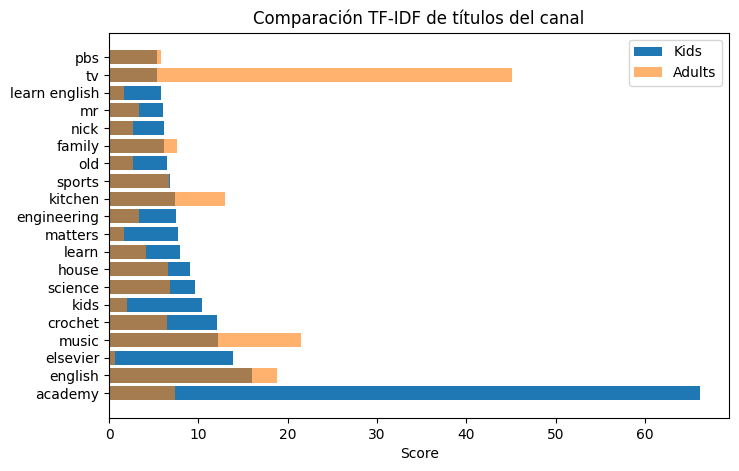

In [14]:
top_terms = common_terms.nlargest(20, "Score_kids")

plt.figure(figsize=(8,5))

plt.barh(top_terms["Titulo_canal"], top_terms["Score_kids"], label="Kids")
plt.barh(top_terms["Titulo_canal"], top_terms["Score_adults"], alpha=0.6, label="Adults")

plt.legend()
plt.title("Comparación TF-IDF de títulos del canal")
plt.xlabel("Score")
plt.show()

En la gráfica podemos ver que los terminos que más salen presentan una distribución equilibrada sin colas largas. A excepción de tv y academy (los términos más representativos como hemos comentado)

In [16]:
topic_model_titulo_canal, df_bertopic_titulo_canal, temas_bertopic_titulo_canal = utils.analizar_bertopic(df_fil, "Titulo_canal")
df_bertopic_titulo_canal_adults, df_bertopic_titulo_canal_kids = utils.division_edad(df_bertopic_titulo_canal)

print(f'Size of Kids: {len(df_bertopic_titulo_canal_kids)}')
print(f'Size of Adults: {len(df_bertopic_titulo_canal_adults)}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Size of Kids: 1273
Size of Adults: 5169


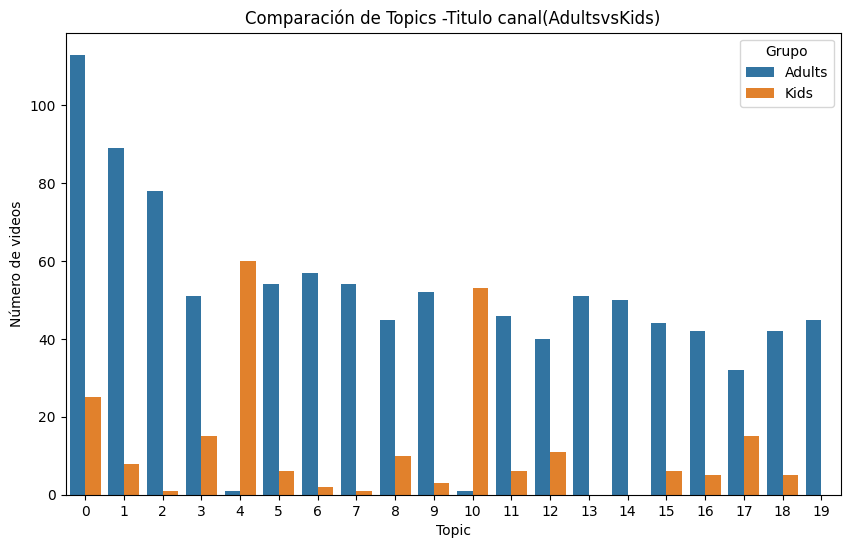

In [17]:
plt.figure(figsize=(10,6))
utils.graficar_bertopic(df_bertopic_titulo_canal_adults, df_bertopic_titulo_canal_kids, "Adults", "Kids", "Titulo canal")
plt.show()

In [19]:
topic_info = topic_model_titulo_canal.get_topic_info()
topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1703,-1_life_the_lý_creative,"[life, the, lý, creative, and, short, ly, worl...","[European Space Agency, ESA, European Space Ag..."
1,0,138,0_anna_mcnulty_bella_coco,"[anna, mcnulty, bella, coco, sarah, dd, holist...","[Anna McNulty, Anna McNulty, Anna McNulty]"
2,1,97,1_krqe_kprc_kpop_kcra,"[krqe, kprc, kpop, kcra, click2houston, ktve, ...","[KRQE, KRQE, KRQE]"
3,2,79,2_bible_holy_jesus_wisdom,"[bible, holy, jesus, wisdom, god, christ, chur...","[The Saints bible study and Prayer Network, Ho..."
4,3,66,3_gaming_game_gamer_games,"[gaming, game, gamer, games, magic, allbash, g...","[allBash Gaming Videos, Magic Gaming, Magic Ga..."
5,4,61,4_khan_academy_india_educators,"[khan, academy, india, educators, parents, fep...","[Khan Academy, Khan Academy, Khan Academy]"
6,5,60,5_cents_market_two_money,"[cents, market, two, money, validation, iron_f...","[Market Validation Lab, Market Validation Lab,..."
7,6,59,6_heart_vision_darkness_shadow,"[heart, vision, darkness, shadow, know, light,...","[No One Know Your Darkness, No One Know Your D..."
8,7,55,7_health_dr_clinic_healthcare,"[health, dr, clinic, healthcare, snaplogic, me...","[Dr. Richard James | Senior Health, Indisputab..."
9,8,55,8_psychology_psych2go_quiet_mind,"[psychology, psych2go, quiet, mind, asapscienc...","[Psych2Go, DARK SIDE PSYCHOLOGY, Quiet Psychol..."


Ocurre lo mismo que con los títulos. La mayor parte de los tópicos están dominados por adultos (Religión, videojuegos, dinero). 

Por otro lado, los tópicos relacionados con Khan Academy, están dominados por niños. 

## Tags


In [20]:
df_freq_tags_adults = utils.frecuencia_tags(df_Adult_fil)
df_freq_tags_kids = utils.frecuencia_tags(df_Kids_fil)
df_tf_tags_adults = utils.tfidf_tags(df_Adult_fil)
df_tf_tags_kids = utils.tfidf_tags(df_Kids_fil)
#df_freq_tags_adults

In [26]:
common_terms = utils.common_terms(df_freq_tags_kids, df_freq_tags_adults, "Tag")
common_terms.sort_values("Frecuencia_adults", ascending=False)


,Tag,Frecuencia_kids,Frecuencia_adults
0,,166,1323
483,news,2,419
145,video,6,160
817,breaking news,1,65
1140,weather,1,64
...,...,...,...
1248,read along,1,1
16,vocabulary,30,1
1247,windows,1,1
1246,inventor,1,1


In [27]:
kids_only, adults_only = utils.exclusive_terms(df_freq_tags_kids, df_freq_tags_adults, "Tag")
print(adults_only.head(10))
kids_only.head(10)

                Tag  Frecuencia
650          news ]         121
117      local news          84
2084        [ local          83
649           local          61
1245  chinese drama          43
1246            ceo          41
3614      live news          39
194         local ]          35
3770   chinesedrama          33
1237         cdrama          32


,Tag,Frecuencia
114,lessons,58
138,health (industry),37
37,engvid,31
38,toefl,29
39,ielts,29
139,medicine (field of study),27
140,disease (cause of death),25
141,osmosis,24
145,nursing school (organization),23
142,pathology (medical specialty),23


Se repite el mismo comportamiento que hemos visto en los títulos. Los vídeos de niños están relacionados con el aprendizaje (lessons) y extrañamente el aprendizaje medico (medicine, desease). 

Mientras que los vídeos para adultos siguen siendo dominados por noticias y actualidad. 

In [28]:
common_terms = utils.common_terms(df_tf_tags_kids, df_tf_tags_adults, "Tag")
common_terms

,Tag,Score_kids,Score_adults,Diff
0,english,215.057544,167.606595,47.450949
1,music,140.483011,400.561346,-260.078335
2,education,130.259899,69.278480,60.981420
3,kids,129.863113,38.462128,91.400985
4,science,115.613249,60.842890,54.770359
...,...,...,...,...
3781,storage,0.341859,24.468332,-24.126474
3782,06,0.341859,0.549870,-0.208011
3783,28,0.341859,2.888097,-2.546239
3784,ve,0.334792,4.208491,-3.873698


In [29]:
kids_only, adults_only = utils.exclusive_terms(df_tf_tags_kids, df_tf_tags_adults, "Tag")
print(adults_only.head(10))
kids_only.head(10)

              Tag       Score
10688       local  285.985609
142          2026  219.910669
4382        crime  109.161182
9201         iran  102.748181
8537       horror   89.385630
9358         jazz   67.202231
11454  meditation   65.661018
1304         arma   57.385470
16962   spiritual   54.751172
17752   talksport   54.660749


,Tag,Score
7118,ted,40.663876
1182,cartoons,36.851517
2452,engvid,31.000000
4515,matemáticas,27.185622
5236,osmosis,24.000000
7149,tennis,23.335255
3680,inglese,23.000000
3262,guitarra,22.396087
8008,إنجليزي,22.000000
378,angielski,21.000000


Si hacemos analisis con TF-IDF vemos que los vídeos de espiritualidad para adultos tienen mayor importancia y para los de niños, los de entretenimiento como cartoons. 

## Descripción

In [30]:
topic_model_descripcion, df_bertopic_descripcion, temas_bertopic_descripcion = utils.analizar_bertopic(df_fil, "Descripcion")
df_bertopic_descripcion_adults, df_bertopic_descripcion_kids = utils.division_edad(df_bertopic_descripcion)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


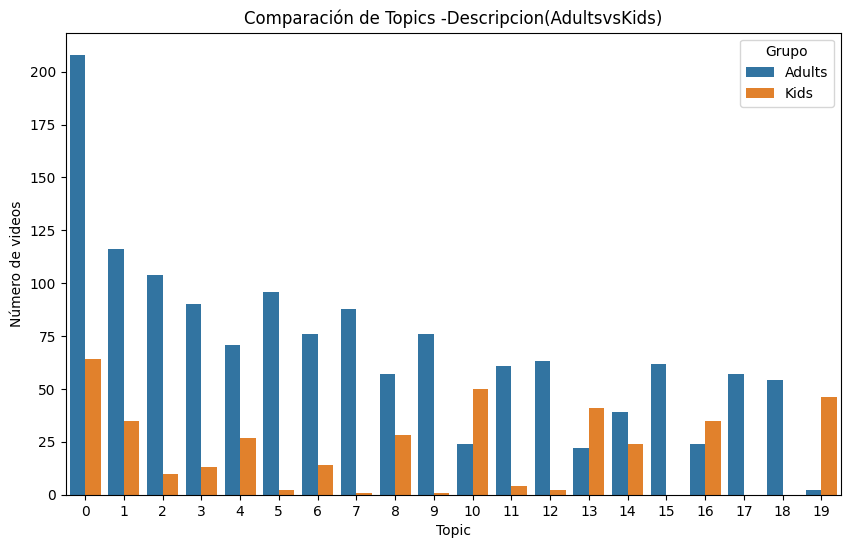

In [31]:
plt.figure(figsize=(10,6))
utils.graficar_bertopic(df_bertopic_descripcion_adults, df_bertopic_descripcion_kids, "Adults", "Kids", "Descripcion")
plt.show()

In [32]:
topic_info = topic_model_descripcion.get_topic_info()
topic_info.head(21)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2754,-1_the_https_and_to,"[the, https, and, to, com, of, www, for, in, you]",[Snug by Carol Thompson. This Story was read b...
1,0,272,0_recipe_recipes_ingredients_tsp,"[recipe, recipes, ingredients, tsp, food, cook...",[📌Turn on CC for step-by-step cooking instruct...
2,1,151,1_https_list_playlist_com,"[https, list, playlist, com, youtube, www, vid...","[Maintain eye contact with your camera, launch..."
3,2,114,2_senate_news_pbs_ms,"[senate, news, pbs, ms, trump, newsmax, now, n...","[Sen. Chris Van Hollen, D-Md., questioned Russ..."
4,3,103,3_market_financial_trading_why,"[market, financial, trading, why, the, stock, ...",[00:00 - The Institutional Barrier Rising\n00:...
5,4,98,4_sports_nbcsports_horse_nbc,"[sports, nbcsports, horse, nbc, college, footb...","[Watch the $600,000 Juddmonte Spinster Stakes ..."
6,5,98,5_weather_forecast_news_local,"[weather, forecast, news, local, more, com, se...",[Overnight severe storms left damage across Me...
7,6,90,6_machine_diy_dialer_oxygenos,"[machine, diy, dialer, oxygenos, oneplus, idea...",[#InventorDIY – DIY #Life Hacks #Creative Idea...
8,7,89,7_music_song_the_love,"[music, song, the, love, you, dark, my, your, ...",[‼️🤩 YOUR Reality. YOUR Lyrics. YOUR Manifesta...
9,8,85,8_fortnite_minecraft_game_sensitivity,"[fortnite, minecraft, game, sensitivity, contr...",[17 must know tips for building pathways in mi...


En los tópicos se ve que adultos domina casi todos, a excepción del tópico relacionado con khan Academy. 

## Subtítulos

In [33]:
topic_model_subtitulos, df_bertopic_subtitulos, temas_bertopic_subtitulos = utils.analizar_bertopic(df_fil, "Subtitulos")
df_bertopic_subtitulos_adults, df_bertopic_subtitulos_kids = utils.division_edad(df_bertopic_subtitulos)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


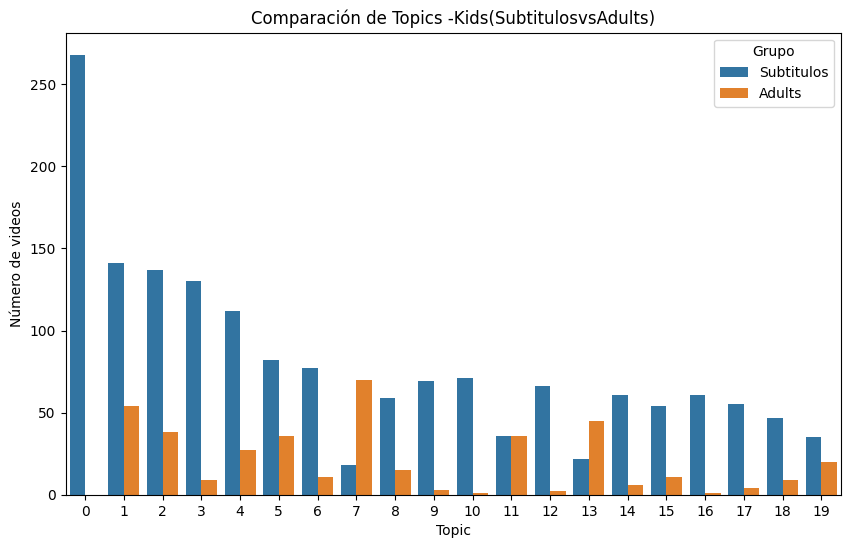

In [34]:
plt.figure(figsize=(10,6))
utils.graficar_bertopic(df_bertopic_subtitulos_adults, df_bertopic_subtitulos_kids, "Subtitulos", "Adults", "Kids")
plt.show()

In [36]:
topic_info = topic_model_subtitulos.get_topic_info()
topic_info.head(21)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2520,-1_the_you_to_nbsp,"[the, you, to, nbsp, and, it, that, of, is, gt]","[Kind: captions Language: en So, come up on on..."
1,0,268,0_police_she_gt_was,"[police, she, gt, was, the, in, they, he, to, ...",[Kind: captions Language: en Good afternoon. A...
2,1,195,1_me_my_you_your,"[me, my, you, your, the, every, in, don, feel,...",[Kind: captions Language: en Yo Trav that girl...
3,2,175,2_add_nbsp_it_and,"[add, nbsp, it, and, little, butter, the, eggs...",[Kind: captions Language: en hey I'm John cane...
4,3,139,3_pageindex_nbsp_language_captions,"[pageindex, nbsp, language, captions, en, rag,...",[Kind: captions Language: en How to break evil...
5,4,139,4_nbsp_you_not_that,"[nbsp, you, not, that, and, your, is, it, to, ...",[Kind: captions Language: en There are pattern...
6,5,118,5_chord_music_note_major,"[chord, music, note, major, of, chords, minor,...","[Kind: captions Language: en - Hi, I'm Gareth ..."
7,6,88,6_gt_game_the_and,"[gt, game, the, and, he, coach, know, they, to...",[Kind: captions Language: en There is a world ...
8,7,88,7_minus_is_so_this,"[minus, is, so, this, we, equal, plus, one, th...",[Kind: captions Language: en [Music] welcome t...
9,8,74,8_none___,"[none, , , , , , , , , ]","[None, None, None]"


Y se repite el mismo comportamiento de tópicos visto anteriormente. 